In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

# import os
# for dirname, _, filenames in os.walk('/kaggle/input'):
#     for filename in filenames:
#         print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

In [2]:
# Define CSRNet model
import torch
import torch.nn as nn

class CSRNet(nn.Module):
    def __init__(self):
        super(CSRNet, self).__init__()
        self.frontend_feat = [64, 64, 'M', 128, 128, 'M', 256, 256, 256, 'M', 512, 512, 512]
        self.frontend = self._make_layers(self.frontend_feat)
        self.backend_feat = [512, 512, 512, 256, 128, 64]
        self.backend = self._make_layers(self.backend_feat, in_channels=512, dilation=True)
        self.output_layer = nn.Conv2d(64, 1, kernel_size=1)
    
    def forward(self, x):
        x = self.frontend(x)
        x = self.backend(x)
        x = self.output_layer(x)
        return x
    
    def _make_layers(self, cfg, in_channels=3, batch_norm=False, dilation=False):
        layers = []
        for x in cfg:
            if x == 'M':
                layers.append(nn.MaxPool2d(kernel_size=2, stride=2))
            else:
                dilation_rate = 2 if dilation else 1
                layers.append(nn.Conv2d(in_channels, x, kernel_size=3, padding=dilation_rate, dilation=dilation_rate))
                if batch_norm:
                    layers.append(nn.BatchNorm2d(x))
                layers.append(nn.ReLU(inplace=True))
                in_channels = x
        return nn.Sequential(*layers)

# Initialize the model
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = CSRNet().to(device)


In [3]:
!ls /kaggle/input


models	shanghaitech


In [4]:
model_weights_path = '/kaggle/input/models/abdelalimchicha/csrnet/pytorch/default/1/weights.pth'
print(str(model_weights_path))

/kaggle/input/models/abdelalimchicha/csrnet/pytorch/default/1/weights.pth


In [5]:
!ls /kaggle/input/models/abdelalimchicha/csrnet/pytorch/default/1/weights.pth

/kaggle/input/models/abdelalimchicha/csrnet/pytorch/default/1/weights.pth


In [6]:
model.load_state_dict(torch.load(model_weights_path, map_location=device))
print("Pretrained weights loaded successfully!")

/tmp/ipykernel_32/2561354198.py:1: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load(model_weights_path, map_location=device))


Pretrained weights loaded successfully!


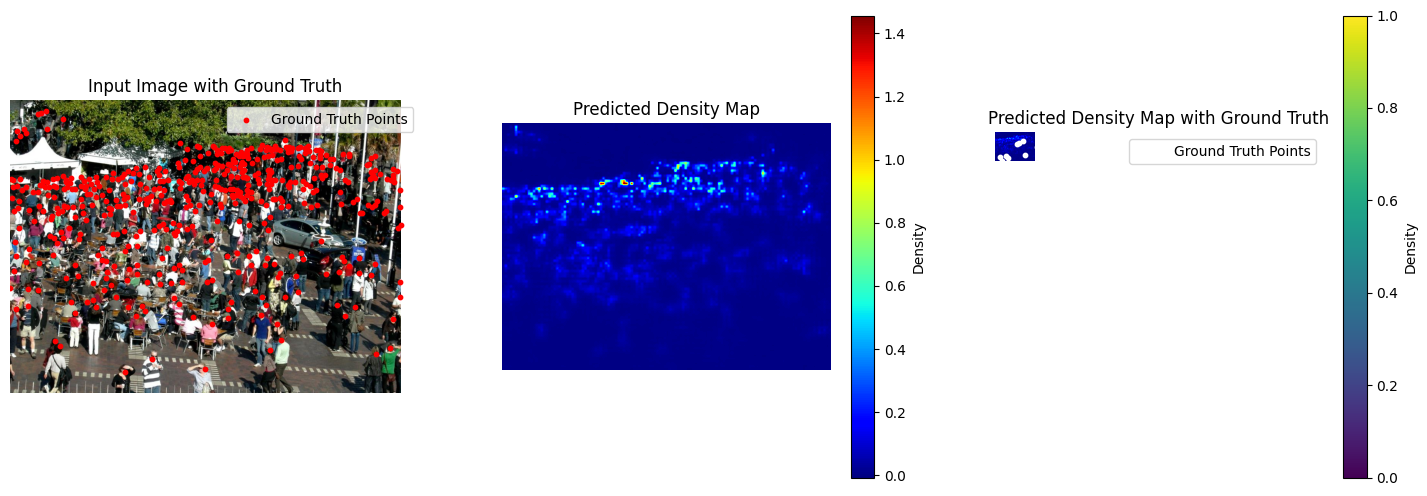

Estimated Crowd Count: 427.07
Actual Ground Truth Count: 502


In [ ]:
# Define CSRNet model
import torch
import torch.nn as nn

class CSRNet(nn.Module):
    def __init__(self):
        super(CSRNet, self).__init__()
        self.frontend_feat = [64, 64, 'M', 128, 128, 'M', 256, 256, 256, 'M', 512, 512, 512]
        self.frontend = self._make_layers(self.frontend_feat)
        self.backend_feat = [512, 512, 512, 256, 128, 64]
        self.backend = self._make_layers(self.backend_feat, in_channels=512, dilation=True)
        self.output_layer = nn.Conv2d(64, 1, kernel_size=1)
    
    def forward(self, x):
        x = self.frontend(x)
        x = self.backend(x)
        x = self.output_layer(x)
        return x
    
    def _make_layers(self, cfg, in_channels=3, batch_norm=False, dilation=False):
        layers = []
        for x in cfg:
            if x == 'M':
                layers.append(nn.MaxPool2d(kernel_size=2, stride=2))
            else:
                dilation_rate = 2 if dilation else 1
                layers.append(nn.Conv2d(in_channels, x, kernel_size=3, padding=dilation_rate, dilation=dilation_rate))
                if batch_norm:
                    layers.append(nn.BatchNorm2d(x))
                layers.append(nn.ReLU(inplace=True))
                in_channels = x
        return nn.Sequential(*layers)

# Initialize the model
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = CSRNet().to(device)


model_weights_path = '/kaggle/input/models/abdelalimchicha/csrnet/pytorch/default/1/weights.pth'
print(str(model_weights_path))

model_weights_path = '/kaggle/input/models/abdelalimchicha/csrnet/pytorch/default/1/weights.pth'
print(str(model_weights_path))

import os
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
import torchvision.transforms as transforms
import scipy.io

# Paths to the test dataset
test_image_path = '/kaggle/input/shanghaitech/ShanghaiTech/part_A/test_data/images/IMG_10.jpg'
ground_truth_path = '/kaggle/input/shanghaitech/ShanghaiTech/part_A/test_data/ground-truth/GT_IMG_10.mat'

# Preprocessing function for input images
def preprocess_image(image_path):
    transform = transforms.Compose([
        transforms.ToTensor(),
        transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
    ])
    image = Image.open(image_path).convert('RGB')
    image = image.resize((1024, 768))  # Resize to model-compatible dimensions
    return transform(image).unsqueeze(0)

# Function to visualize predictions and ground truth
def predict_and_visualize_with_ground_truth(image_path, ground_truth_path):
    # Load and preprocess the image
    image = preprocess_image(image_path).to(device)

    # Get the predicted density map
    density_map = model(image).detach().cpu().numpy().squeeze(0).squeeze(0)

    # Load the ground truth data
    gt_data = scipy.io.loadmat(ground_truth_path)
    points = gt_data['image_info'][0][0][0][0][0]  # Ground truth points

    # Display the input image, ground truth, and predicted density map
    plt.figure(figsize=(18, 6))

    # Input image with ground truth points
    plt.subplot(1, 3, 1)
    plt.imshow(Image.open(image_path))
    plt.scatter(points[:, 0], points[:, 1], c='red', s=10, label='Ground Truth Points')
    plt.title('Input Image with Ground Truth')
    plt.legend()
    plt.axis('off')

    # Predicted density map
    plt.subplot(1, 3, 2)
    plt.imshow(density_map, cmap='jet')
    plt.colorbar(label='Density')
    plt.title('Predicted Density Map')
    plt.axis('off')

    # Overlay ground truth points on density map
    plt.subplot(1, 3, 3)
    plt.imshow(density_map, cmap='jet')
    plt.scatter(points[:, 0], points[:, 1], c='white', s=10, label='Ground Truth Points')
    plt.colorbar(label='Density')
    plt.title('Predicted Density Map with Ground Truth')
    plt.legend()
    plt.axis('off')

    plt.show()

    # Calculate and print the estimated and actual crowd counts
    estimated_count = np.sum(density_map)
    actual_count = len(points)
    print(f"Estimated Crowd Count: {estimated_count:.2f}")
    print(f"Actual Ground Truth Count: {actual_count}")

# Test the model on the specified image
predict_and_visualize_with_ground_truth(test_image_path, ground_truth_path)
